In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pyproj import Transformer
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from scipy.interpolate import InterpolatedUnivariateSpline

In [2]:
%store -r cn0dbhz_merge_df
%store -r satcount_merge_df
%store -r elevationdeg_merge_df
%store -r acc_merge_df
%store -r gyro_merge_df
# %store -r energy_merge_df

%store -r satcountdelta_merge_df
# %store -r energydelta_merge_df
%store -r cn0dbhzdelta_merge_df
%store -r cn0dbhzmean_merge_df
# %store -r energystd_merge_df
# %store -r clarity_merge_df

In [3]:
merge_df = cn0dbhz_merge_df.merge(satcount_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCount']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(elevationdeg_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SvElevationDegrees']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(acc_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'AccMag']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(gyro_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'GyroMag']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energy_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'TotalMotionEnergy']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

merge_df = merge_df.merge(satcountdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCountDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energydelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzmean_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzMean']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energystd_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyStd']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(clarity_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SignalClarity']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

In [4]:
print(merge_df.isna().sum())

drive_id               0
device                 0
UnixTimeMillis         0
Cn0DbHz                0
ErrorXEcefMeters       0
ErrorYEcefMeters       0
ErrorZEcefMeters       0
SatCount               0
SvElevationDegrees    22
AccMag                 0
GyroMag                0
SatCountDelta          0
Cn0DbHzDelta           0
Cn0DbHzMean            0
dtype: int64


In [5]:
# drop null values

# merge_df = merge_df.dropna(subset=['SvElevationDegrees', 'TotalMotionEnergy'])
merge_df = merge_df.dropna(subset=['SvElevationDegrees'])

print(merge_df.isna().sum())
print()
print('Merge Shape: ')
print(merge_df.shape)
print()

drive_id              0
device                0
UnixTimeMillis        0
Cn0DbHz               0
ErrorXEcefMeters      0
ErrorYEcefMeters      0
ErrorZEcefMeters      0
SatCount              0
SvElevationDegrees    0
AccMag                0
GyroMag               0
SatCountDelta         0
Cn0DbHzDelta          0
Cn0DbHzMean           0
dtype: int64

Merge Shape: 
(157514, 14)



In [6]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorXEcefMeters'])

In [7]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
modelx_lr = LinearRegression()
modelx_lr.fit(X_train, y_train)

train_res_x = y_train - modelx_lr.predict(X_train)
test_res_x = y_test - modelx_lr.predict(X_test)

In [9]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 15,
    'min_data_in_leaf': 100,
    'verbosity': -1
}

In [10]:
dtrain_x = lgb.Dataset(X_train, label=train_res_x)
dtest_x = lgb.Dataset(X_test, label=test_res_x)

In [11]:
modelx_gbm = lgb.train(params, dtrain_x, num_boost_round=2000, 
                           valid_sets=[dtest_x], 
                           callbacks=[lgb.early_stopping(50), lgb.log_evaluation(period=50)])

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.8291
[100]	valid_0's rmse: 1.77326
[150]	valid_0's rmse: 1.74006
[200]	valid_0's rmse: 1.71944
[250]	valid_0's rmse: 1.70427
[300]	valid_0's rmse: 1.69192
[350]	valid_0's rmse: 1.68326
[400]	valid_0's rmse: 1.67637
[450]	valid_0's rmse: 1.671
[500]	valid_0's rmse: 1.66555
[550]	valid_0's rmse: 1.66083
[600]	valid_0's rmse: 1.65579
[650]	valid_0's rmse: 1.65099
[700]	valid_0's rmse: 1.64701
[750]	valid_0's rmse: 1.64306
[800]	valid_0's rmse: 1.6394
[850]	valid_0's rmse: 1.63577
[900]	valid_0's rmse: 1.63216
[950]	valid_0's rmse: 1.62881
[1000]	valid_0's rmse: 1.6262
[1050]	valid_0's rmse: 1.62305
[1100]	valid_0's rmse: 1.62039
[1150]	valid_0's rmse: 1.61739
[1200]	valid_0's rmse: 1.61492
[1250]	valid_0's rmse: 1.6125
[1300]	valid_0's rmse: 1.61035
[1350]	valid_0's rmse: 1.60799
[1400]	valid_0's rmse: 1.60628
[1450]	valid_0's rmse: 1.60422
[1500]	valid_0's rmse: 1.60226
[1550]	valid_0's rmse: 1.60048
[160

In [12]:
final_pred_x = modelx_lr.predict(X_test) + modelx_gbm.predict(X_test)

In [13]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorYEcefMeters'])

In [14]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
modely_lr = LinearRegression()
modely_lr.fit(X_train, y_train)

train_res_y = y_train - modely_lr.predict(X_train)
test_res_y = y_test - modely_lr.predict(X_test)

In [16]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 15,
    'min_data_in_leaf': 100,
    'verbosity': -1
}

In [17]:
dtrain_y = lgb.Dataset(X_train, label=train_res_y)
dtest_y = lgb.Dataset(X_test, label=test_res_y)

In [18]:
modely_gbm = lgb.train(params, dtrain_y, num_boost_round=2000, 
                           valid_sets=[dtest_y], 
                           callbacks=[lgb.early_stopping(50), lgb.log_evaluation(period=50)])

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 2.4376
[100]	valid_0's rmse: 2.38973
[150]	valid_0's rmse: 2.36094
[200]	valid_0's rmse: 2.33391
[250]	valid_0's rmse: 2.31301
[300]	valid_0's rmse: 2.29816
[350]	valid_0's rmse: 2.28567
[400]	valid_0's rmse: 2.27529
[450]	valid_0's rmse: 2.2663
[500]	valid_0's rmse: 2.25782
[550]	valid_0's rmse: 2.25086
[600]	valid_0's rmse: 2.2446
[650]	valid_0's rmse: 2.23922
[700]	valid_0's rmse: 2.23345
[750]	valid_0's rmse: 2.22883
[800]	valid_0's rmse: 2.22335
[850]	valid_0's rmse: 2.21825
[900]	valid_0's rmse: 2.21294
[950]	valid_0's rmse: 2.20842
[1000]	valid_0's rmse: 2.20492
[1050]	valid_0's rmse: 2.20036
[1100]	valid_0's rmse: 2.19646
[1150]	valid_0's rmse: 2.19135
[1200]	valid_0's rmse: 2.18757
[1250]	valid_0's rmse: 2.18458
[1300]	valid_0's rmse: 2.18179
[1350]	valid_0's rmse: 2.17923
[1400]	valid_0's rmse: 2.17658
[1450]	valid_0's rmse: 2.17436
[1500]	valid_0's rmse: 2.17114
[1550]	valid_0's rmse: 2.16862
[

In [19]:
final_pred_y = modely_lr.predict(X_test) + modely_gbm.predict(X_test)

In [20]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorZEcefMeters'])

In [21]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
modelz_lr = LinearRegression()
modelz_lr.fit(X_train, y_train)

train_res_z = y_train - modelz_lr.predict(X_train)
test_res_z = y_test - modelz_lr.predict(X_test)

In [23]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 15,
    'min_data_in_leaf': 100,
    'verbosity': -1
}

In [24]:
dtrain_z = lgb.Dataset(X_train, label=train_res_z)
dtest_z = lgb.Dataset(X_test, label=test_res_z)

In [25]:
modelz_gbm = lgb.train(params, dtrain_z, num_boost_round=2000, 
                           valid_sets=[dtest_z], 
                           callbacks=[lgb.early_stopping(50), lgb.log_evaluation(period=50)])

Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 2.44426
[100]	valid_0's rmse: 2.37392
[150]	valid_0's rmse: 2.33477
[200]	valid_0's rmse: 2.30968
[250]	valid_0's rmse: 2.28578
[300]	valid_0's rmse: 2.26729
[350]	valid_0's rmse: 2.25311
[400]	valid_0's rmse: 2.24203
[450]	valid_0's rmse: 2.23116
[500]	valid_0's rmse: 2.22171
[550]	valid_0's rmse: 2.21436
[600]	valid_0's rmse: 2.20648
[650]	valid_0's rmse: 2.1995
[700]	valid_0's rmse: 2.19338
[750]	valid_0's rmse: 2.18806
[800]	valid_0's rmse: 2.18307
[850]	valid_0's rmse: 2.17847
[900]	valid_0's rmse: 2.17352
[950]	valid_0's rmse: 2.16814
[1000]	valid_0's rmse: 2.164
[1050]	valid_0's rmse: 2.1604
[1100]	valid_0's rmse: 2.15691
[1150]	valid_0's rmse: 2.15355
[1200]	valid_0's rmse: 2.15011
[1250]	valid_0's rmse: 2.14578
[1300]	valid_0's rmse: 2.1422
[1350]	valid_0's rmse: 2.13876
[1400]	valid_0's rmse: 2.13588
[1450]	valid_0's rmse: 2.13315
[1500]	valid_0's rmse: 2.1306
[1550]	valid_0's rmse: 2.1285
[1600

In [26]:
final_pred_z = modelz_lr.predict(X_test) + modelz_gbm.predict(X_test)

In [27]:
%store -r merge_test_df

In [28]:
print(merge_test_df)

       UnixTimeMillis    Cn0DbHz  SatCount  SvElevationDegrees  \
0       1619650832999  27.599822        39           38.017116   
1       1619650833999  27.793549        39           38.015823   
2       1619650834999  27.486261        39           37.268639   
3       1619650835999  27.419616        39           37.267143   
4       1619650836999  28.162419        39           38.337918   
...               ...        ...       ...                 ...   
66092   1650927742650  33.194444        18           34.795333   
66093   1650927743642  32.882353        17           35.171023   
66094   1650927744651  32.980952        21           35.621820   
66095   1650927745640  32.850000        20           37.707205   
66096   1650927746632  32.785714        21           35.621205   

                                          tripId    AccMag   GyroMag  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra  9.759161  0.007877   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra  9.854152  0.0

In [29]:
# features_test_df = merge_test_df.drop(columns=['UnixTimeMillis', 'tripId', 'WlsPositionXEcefMeters','WlsPositionYEcefMeters', 'WlsPositionZEcefMeters'])
features_test_df = merge_test_df.drop(columns=['UnixTimeMillis', 'tripId', 'x_kf','y_kf', 'z_kf'])

predicted_errorx = modelx_lr.predict(features_test_df) + modelx_gbm.predict(features_test_df)
predicted_errory = modely_lr.predict(features_test_df) + modely_gbm.predict(features_test_df)
predicted_errorz = modelz_lr.predict(features_test_df) + modelz_gbm.predict(features_test_df)

print('predicted_errorx: ')
print(predicted_errorx)
print()
print('predicted_errory: ')
print(predicted_errory)
print()
print('predicted_errorz: ')
print(predicted_errorz)
print()

predicted_errorx: 
[ 0.1916947   0.13793859  0.20316621 ... -1.04174114 -1.01515449
 -0.94558603]

predicted_errory: 
[-1.266726   -1.35384979 -1.19664592 ... -1.37315842 -1.35422364
 -1.17510655]

predicted_errorz: 
[ 0.14486212  0.35011603 -0.22437711 ...  0.19298182  0.33870107
  0.2105394 ]



In [30]:
submission_ecef = pd.DataFrame()
submission_ecef['MeasurementX_Corr'] = merge_test_df['x_kf'] + predicted_errorx
submission_ecef['MeasurementY_Corr'] = merge_test_df['y_kf'] + predicted_errory
submission_ecef['MeasurementZ_Corr'] = merge_test_df['z_kf'] + predicted_errorz

In [31]:
transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

lon, lat, alt = transformer.transform(
    submission_ecef['MeasurementX_Corr'].values, 
    submission_ecef['MeasurementY_Corr'].values,
    submission_ecef['MeasurementZ_Corr'].values,
)

In [32]:
submission = pd.DataFrame()
submission['tripId'] = merge_test_df['tripId']
submission['UnixTimeMillis'] = merge_test_df['UnixTimeMillis']
submission['LatitudeDegrees'] = lat
submission['LongitudeDegrees'] = lon

print(submission)
print()

                                          tripId  UnixTimeMillis  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650832999   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650833999   
2      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650834999   
3      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650835999   
4      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650836999   
...                                          ...             ...   
66092           2022-04-25-US-OAK-2/GooglePixel4   1650927742650   
66093           2022-04-25-US-OAK-2/GooglePixel4   1650927743642   
66094           2022-04-25-US-OAK-2/GooglePixel4   1650927744651   
66095           2022-04-25-US-OAK-2/GooglePixel4   1650927745640   
66096           2022-04-25-US-OAK-2/GooglePixel4   1650927746632   

       LatitudeDegrees  LongitudeDegrees  
0            37.395757       -122.102960  
1            37.395758       -122.102960  
2            37.395754       -122.102961  
3          

In [33]:
def remove_spikes(df):
    dist_lat = df.groupby('tripId')['LatitudeDegrees'].diff().abs()
    dist_lng = df.groupby('tripId')['LongitudeDegrees'].diff().abs()
    
    mask = (dist_lat > 0.0005) | (dist_lng > 0.0005)
    
    df.loc[mask, ['LatitudeDegrees', 'LongitudeDegrees']] = np.nan
    
    return df.groupby('tripId').apply(lambda group: group.interpolate())

In [34]:
def apply_savgol_filter(df, window=11, poly=3):
    df = df.reset_index(drop=True)
    df_out = df.copy()
    
    for trip_id, trip_df in df_out.groupby('tripId'):
        
        if len(trip_df) > window:
            df_out.loc[trip_df.index, 'LatitudeDegrees'] = savgol_filter(trip_df['LatitudeDegrees'], window, poly)
            df_out.loc[trip_df.index, 'LongitudeDegrees'] = savgol_filter(trip_df['LongitudeDegrees'], window, poly)

    return df_out

In [35]:
submission = remove_spikes(submission)
submission = apply_savgol_filter(submission)

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_4266/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_4266/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_4266/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1k

In [37]:
# def apply_spline(df):
#     # Sort just in case
#     df = df.sort_values('UnixTimeMillis')
    
#     # We only interpolate if we have enough points (need at least k+1 points)
#     if len(df) > 3:
#         # Interpolate Lat
#         spl_lat = InterpolatedUnivariateSpline(df['UnixTimeMillis'], df['LatitudeDegrees'], k=3)
#         df['LatitudeDegrees'] = spl_lat(df['UnixTimeMillis'])
        
#         # Interpolate Lng
#         spl_lng = InterpolatedUnivariateSpline(df['UnixTimeMillis'], df['LongitudeDegrees'], k=3)
#         df['LongitudeDegrees'] = spl_lng(df['UnixTimeMillis'])
#     return df

# # Apply it to each trip separately
# submission = submission.groupby('tripId', group_keys=False).apply(apply_spline)

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_4266/916555615.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  submission = submission.groupby('tripId', group_keys=False).apply(apply_spline)


In [38]:
print(submission)
print()
submission.to_csv('./SUBMISSIONS/DUMP/submission.csv', index=False)

                                          tripId  UnixTimeMillis  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650832999   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650833999   
2      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650834999   
3      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650835999   
4      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650836999   
...                                          ...             ...   
66092           2022-04-25-US-OAK-2/GooglePixel4   1650927742650   
66093           2022-04-25-US-OAK-2/GooglePixel4   1650927743642   
66094           2022-04-25-US-OAK-2/GooglePixel4   1650927744651   
66095           2022-04-25-US-OAK-2/GooglePixel4   1650927745640   
66096           2022-04-25-US-OAK-2/GooglePixel4   1650927746632   

       LatitudeDegrees  LongitudeDegrees  
0            37.395756       -122.102959  
1            37.395757       -122.102963  
2            37.395757       -122.102962  
3          

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_4266/3209146778.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])


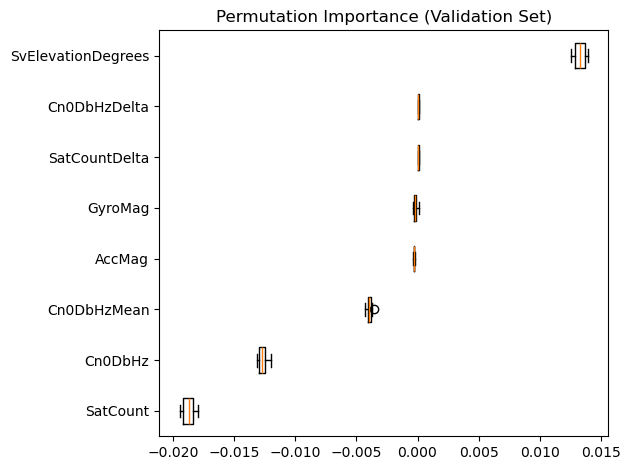

In [39]:
result = permutation_importance(
    modelx_lr, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_train.columns[sorted_idx])
plt.title("Permutation Importance (Validation Set)")
plt.tight_layout()
plt.show()